# Exemplo 05 - Bastidores: como uma rede neural aprende

### Palestra Machine Learning e IA: Da máquina que aprende à IA que age

### Prof. Dr. Ahirton Lopes (https://github.com/ahirtonlopes)

**Onde isso aparece no mercado:** Todo modelo de deep learning que você usa, do desbloqueio facial do celular aos LLMs, foi treinado ajustando seus pesos com alguma variação da descida do gradiente.

**Conceito da palestra:** Aprender é minimizar o erro: a rede dá pequenos passos na direção que mais reduz a perda.

Bem-vindo a este notebook introdutório sobre deep learning! Nosso objetivo aqui é entender três conceitos fundamentais que são cruciais para construir e treinar redes neurais:

1.  **Descida do Gradiente (Gradient Descent)**: Como as redes neurais aprendem ajustando seus parâmetros.
2.  **Funções de Ativação**: Por que as não-linearidades são essenciais nas redes neurais.
3.  **Camadas**: Os blocos de construção básicos de uma rede neural.

Mesmo antes de mergulhar em arquiteturas complexas como Perceptrons Multi-Camadas (MLPs), compreender essas ideias fornecerá uma base sólida para sua jornada no deep learning.

## 1. Descida do Gradiente: O Algoritmo de Aprendizagem

Imagine que você está no topo de uma colina e deseja chegar ao fundo (o ponto mais baixo). Você não consegue ver toda a paisagem, mas pode sentir a inclinação ao seu redor. Para chegar ao fundo, você daria um pequeno passo na direção que desce mais abruptamente.

Em machine learning, essa 'colina' é frequentemente representada por uma **função de perda** (ou função de custo), que mede o quão 'erradas' são as previsões do nosso modelo. Nosso objetivo é encontrar os parâmetros (pesos e vieses) do modelo que minimizam essa função de perda. A Descida do Gradiente é um algoritmo de otimização usado para fazer exatamente isso.

### Como funciona:
1.  **Comece com parâmetros iniciais**: Começamos com algumas suposições aleatórias para os parâmetros do modelo.
2.  **Calcule o gradiente**: Determinamos a 'inclinação' da função de perda em relação a cada parâmetro. O gradiente aponta na direção da subida mais íngreme.
3.  **Atualize os parâmetros**: Movemo-nos na direção oposta ao gradiente (ladeira abaixo) por uma pequena quantidade. Essa quantidade é controlada por um valor chamado **taxa de aprendizado**.
4.  **Repita**: Repetimos os passos 2 e 3 muitas vezes até que a função de perda seja minimizada (ou pare de diminuir significativamente).

### Um Exemplo Simples: Encontrando o Mínimo de uma Função Quadrática

Vamos visualizar a Descida do Gradiente com uma função muito simples: $f(x) = x^2$. Nosso objetivo é encontrar o valor de $x$ que minimiza $f(x)$ (que sabemos ser $x=0$).

A derivada de $f(x) = x^2$ é $f'(x) = 2x$. Essa derivada nos dá a inclinação (gradiente) em qualquer ponto $x$.

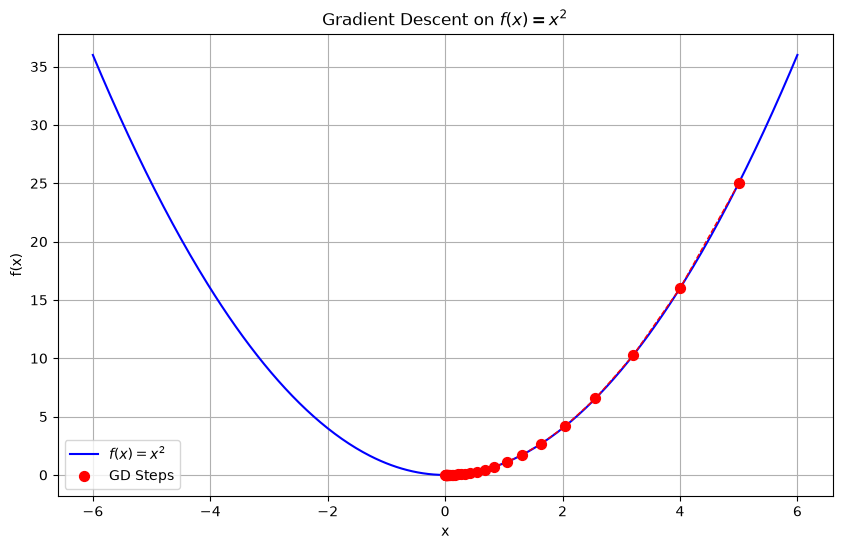

Final x value after 30 iterations: 0.0062
Minimum value of f(x) found: 0.0000


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define the function and its derivative
def func(x):
    return x**2

def derivative(x):
    return 2 * x

# Gradient Descent parameters
learning_rate = 0.1
initial_x = 5.0 # Starting point
iterations = 30

# Store the history of x and y values
x_history = [initial_x]
y_history = [func(initial_x)]

x = initial_x
for i in range(iterations):
    grad = derivative(x)
    x = x - learning_rate * grad # Update x: move opposite to the gradient
    x_history.append(x)
    y_history.append(func(x))

# Plotting
fig = plt.figure(figsize=(10, 6))

# Generate points for the function curve
x_vals = np.linspace(-6, 6, 400)
y_vals = func(x_vals)

plt.plot(x_vals, y_vals, label='$f(x) = x^2$', color='blue')
plt.scatter(x_history, y_history, color='red', s=50, zorder=5, label='GD Steps')
plt.plot(x_history, y_history, color='red', linestyle='--', linewidth=1)

plt.title('Gradient Descent on $f(x) = x^2$')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True)
plt.legend()
plt.show()

print(f"Final x value after {iterations} iterations: {x_history[-1]:.4f}")
print(f"Minimum value of f(x) found: {y_history[-1]:.4f}")

## 2. Funções de Ativação: Adicionando Não-linearidade

Se uma rede neural fosse composta apenas por combinações lineares de suas entradas (pesos e somas), ela seria capaz de aprender apenas relações lineares. Isso significa que, independentemente de quantas camadas a rede tivesse, ela se comportaria como uma única camada linear.

As **funções de ativação** são introduzidas nas redes neurais para adicionar não-linearidade. Elas transformam a soma ponderada das entradas de um neurônio em uma saída. Essa capacidade de modelar relações não-lineares é o que permite que as redes neurais aprendam padrões complexos em dados.

### Propriedades Chave:
*   **Não-linearidade**: Permitem que a rede aprenda funções complexas.
*   **Derivável**: Para que a descida do gradiente possa ser aplicada, a função de ativação deve ser derivável (ou ter uma derivada subgradiente em todos os pontos).

### Exemplos Comuns de Funções de Ativação:

1.  **Sigmoid**: Comprime a entrada para um intervalo entre 0 e 1. Costumava ser popular na camada de saída para problemas de classificação binária.
    $f(x) = \frac{1}{1 + e^{-x}}$

2.  **ReLU (Rectified Linear Unit)**: É a função de ativação mais popular atualmente. Simplesmente retorna a entrada se for positiva, caso contrário, retorna zero.
    $f(x) = \text{max}(0, x)$

3.  **Tanh (Tangente Hiperbólica)**: Comprime a entrada para um intervalo entre -1 e 1. Similar à Sigmoid, mas centrada em zero.
    $f(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$

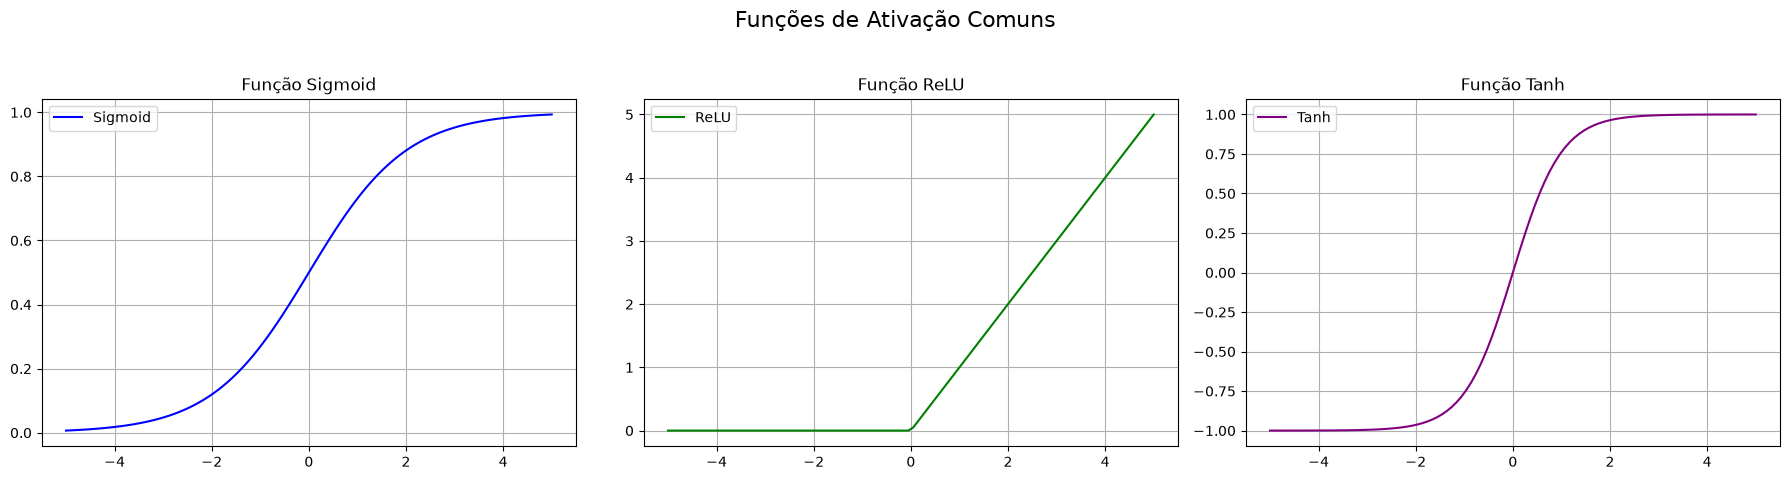

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Define activation functions
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def relu(x):
    return np.maximum(0, x)

def tanh(x):
    return np.tanh(x)

# Generate input values
x_vals = np.linspace(-5, 5, 100)

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Funções de Ativação Comuns', fontsize=16)

# Sigmoid
axes[0].plot(x_vals, sigmoid(x_vals), label='Sigmoid', color='blue')
axes[0].set_title('Função Sigmoid')
axes[0].grid(True)
axes[0].legend()

# ReLU
axes[1].plot(x_vals, relu(x_vals), label='ReLU', color='green')
axes[1].set_title('Função ReLU')
axes[1].grid(True)
axes[1].legend()

# Tanh
axes[2].plot(x_vals, tanh(x_vals), label='Tanh', color='purple')
axes[2].set_title('Função Tanh')
axes[2].grid(True)
axes[2].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 3. Camadas (Layers): Blocos de Construção das Redes Neurais

Uma rede neural é essencialmente uma pilha de **camadas**. Cada camada é composta por um conjunto de neurônios (ou unidades de processamento) que recebem entradas, realizam uma computação (soma ponderada seguida por uma função de ativação) e passam sua saída para a próxima camada.

Existem três tipos principais de camadas em uma rede neural básica:

1.  **Camada de Entrada (Input Layer)**: Esta é a primeira camada da rede. Ela recebe os dados brutos de entrada (por exemplo, pixels de uma imagem, características de um dataset). O número de neurônios na camada de entrada geralmente corresponde ao número de características nos dados de entrada.

2.  **Camadas Ocultas (Hidden Layers)**: São as camadas entre a camada de entrada e a camada de saída. O termo 'ocultas' vem do fato de que elas não estão diretamente expostas aos dados de entrada nem à saída final. Estas camadas realizam a maior parte do trabalho computacional, aprendendo representações cada vez mais abstratas dos dados. Uma rede pode ter uma ou muitas camadas ocultas; quanto mais camadas ocultas, mais 'profunda' é a rede (daí o termo 'Deep Learning').

3.  **Camada de Saída (Output Layer)**: Esta é a última camada da rede. Ela produz o resultado final do modelo (por exemplo, a probabilidade de uma imagem ser um cachorro, um valor predito para o preço de uma casa). O número de neurônios na camada de saída e a função de ativação utilizada dependem do tipo de problema que a rede está tentando resolver (e.g., classificação, regressão).

### Como as Camadas Trabalham Juntas

Imagine uma linha de montagem:
*   A **camada de entrada** recebe as peças brutas (dados).
*   As **camadas ocultas** processam e transformam essas peças em componentes mais complexos, adicionando detalhes e abstrações.
*   A **camada de saída** monta os componentes finais para produzir o produto acabado (a previsão ou decisão da rede).

Cada conexão entre neurônios de camadas adjacentes tem um **peso** associado a ela, e cada neurônio tem um **viés**. Durante o treinamento, a Descida do Gradiente ajusta esses pesos e vieses para minimizar a função de perda, permitindo que a rede aprenda a fazer previsões precisas.

## Conclusão: Unindo os Conceitos

Neste notebook, exploramos os três pilares fundamentais do deep learning:

*   **Descida do Gradiente**: É o "motor" que permite que a rede aprenda. Ele ajusta os pesos e vieses das conexões entre os neurônios, movendo-se na direção que minimiza a função de perda.

*   **Funções de Ativação**: Inserem a não-linearidade necessária em cada neurônio dentro das camadas ocultas. Sem elas, mesmo uma rede com muitas camadas seria equivalente a uma única camada linear, limitando severamente sua capacidade de modelar dados complexos.

*   **Camadas**: São os organizadores da rede. A camada de entrada recebe os dados, as camadas ocultas extraem características e transformam a informação, e a camada de saída entrega o resultado final.

### Como tudo se encaixa em uma rede neural:

1.  **Dados de entrada** são alimentados na **camada de entrada**.
2.  Cada neurônio nas **camadas ocultas** realiza uma soma ponderada de suas entradas, adiciona um viés e, em seguida, aplica uma **função de ativação** para produzir uma saída não-linear.
3.  Essa saída se torna a entrada para a próxima camada, e o processo se repete até a **camada de saída**.
4.  A saída da rede é comparada com a saída esperada usando uma **função de perda**.
5.  A **Descida do Gradiente** usa o valor da função de perda para calcular como os pesos e vieses devem ser ajustados para diminuir o erro, propagando essa informação de volta através da rede (processo conhecido como *backpropagation*, que é a base da Descida do Gradiente em redes neurais).

Ao combinar esses três elementos, somos capazes de construir redes neurais profundas que podem aprender e modelar uma incrível variedade de padrões complexos em dados, desde o reconhecimento de imagens até a compreensão de linguagem natural.